In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import os
os.makedirs("../results/03", exist_ok = True)

In [4]:
df = pd.read_csv("../data/processed/tpd_2018_2025.csv", low_memory = False)
df.head()

,IncidentID,Year,Month,Day,Hour,Division,Ward,UCR,UCRDescription,Offense,CallSource
0,112318516Z,2022,January,Sat,0,West,0,6,06 - LARCENY,603,Web Reported
1,009240162Z,2022,March,Tue,13,West,1,2,02 - SEXUAL ASSAULT,203,Unknown
2,1210180043,2019,February,Tue,3,South,5,1,01 - HOMICIDE,101,Unknown
3,1801010290,2018,January,Mon,10,West,1,7,07 - GTA,701,Call For Service
4,1801010146,2018,January,Mon,4,South,5,4,"04 - ASSAULT, AGGRAVATED",403,Call For Service


In [5]:
# drop columns not used for modeling
df = df.drop(columns = ["IncidentID", "UCR", "Offense"])

# one-hot encode categorical columns
df = pd.get_dummies(df, columns = ["Division", "CallSource", "Ward", "Month", "Day"], drop_first = True)

print(df.shape)
print(df.head())


(243127, 33)
   Year  Hour            UCRDescription  Division_Midtown  Division_South  \
0  2022     0              06 - LARCENY             False           False   
1  2022    13       02 - SEXUAL ASSAULT             False           False   
2  2019     3             01 - HOMICIDE             False            True   
3  2018    10                  07 - GTA             False           False   
4  2018     4  04 - ASSAULT, AGGRAVATED             False            True   

   Division_West  CallSource_Detectiv  CallSource_Officer-Initiated  \
0           True                False                         False   
1           True                False                         False   
2          False                False                         False   
3           True                False                         False   
4          False                False                         False   

   CallSource_Unknown  CallSource_Web Reported  ...  Month_May  \
0               False          

In [6]:
X = df.drop(columns = ["UCRDescription"])
y = df["UCRDescription"]

print(X.shape, y.shape)
print(y.value_counts())

(243127, 32) (243127,)
UCRDescription
06 - LARCENY                170264
05 - BURGLARY                21409
07 - GTA                     19227
04 - ASSAULT, AGGRAVATED     18465
03 - ROBBERY                  8188
02 - SEXUAL ASSAULT           3534
08 - ARSON                    1512
01 - HOMICIDE                  528
Name: count, dtype: int64


In [7]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size = 0.2, random_state = 42, stratify = y_encoded)
print(X_train.shape, X_test.shape)

(194501, 32) (48626, 32)


In [9]:
le.classes_

array(['01 - HOMICIDE', '02 - SEXUAL ASSAULT', '03 - ROBBERY',
       '04 - ASSAULT, AGGRAVATED', '05 - BURGLARY', '06 - LARCENY',
       '07 - GTA', '08 - ARSON'], dtype=object)

In [10]:
rf = RandomForestClassifier(random_state = 42, n_jobs = -1)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


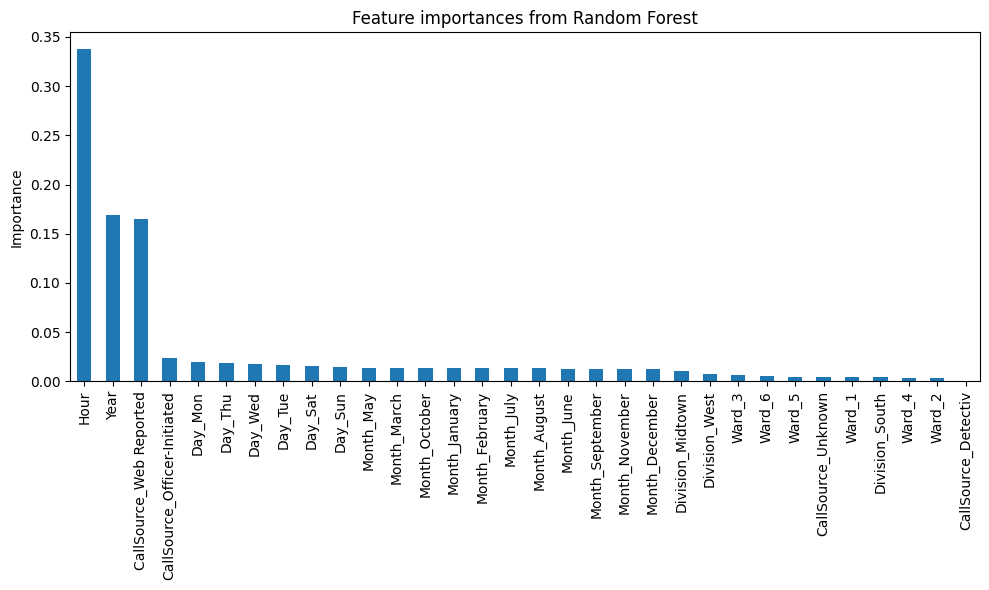

In [11]:
importances = pd.Series(rf.feature_importances_, index = X.columns)
importances = importances.sort_values(ascending = False)

plt.figure(figsize = (10, 6))
importances.plot(kind = "bar")
plt.title("Feature importances from Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("../results/03/feature_importances.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [12]:
selected_features = importances[importances > 0.01].index.tolist()
print(selected_features)
print(f"Number of selected features: {len(selected_features)}")

['Hour', 'Year', 'CallSource_Web Reported', 'CallSource_Officer-Initiated', 'Day_Mon', 'Day_Thu', 'Day_Wed', 'Day_Tue', 'Day_Sat', 'Day_Sun', 'Month_May', 'Month_March', 'Month_October', 'Month_January', 'Month_February', 'Month_July', 'Month_August', 'Month_June', 'Month_September', 'Month_November', 'Month_December', 'Division_Midtown']
Number of selected features: 22


In [13]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

In [15]:
# Multinomial Logistic Regression

lr_model = LogisticRegression(solver = 'lbfgs', max_iter = 1000, random_state = 42, class_weight = 'balanced')
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

lr_report = classification_report(y_test, lr_predictions, target_names = le.classes_)
print(lr_report)

                          precision    recall  f1-score   support

           01 - HOMICIDE       0.00      0.40      0.01       106
     02 - SEXUAL ASSAULT       0.02      0.12      0.04       707
            03 - ROBBERY       0.07      0.26      0.11      1638
04 - ASSAULT, AGGRAVATED       0.18      0.11      0.14      3693
           05 - BURGLARY       0.21      0.10      0.13      4282
            06 - LARCENY       0.97      0.60      0.74     34053
                07 - GTA       0.19      0.06      0.09      3845
              08 - ARSON       0.01      0.17      0.02       302

                accuracy                           0.45     48626
               macro avg       0.21      0.23      0.16     48626
            weighted avg       0.73      0.45      0.55     48626



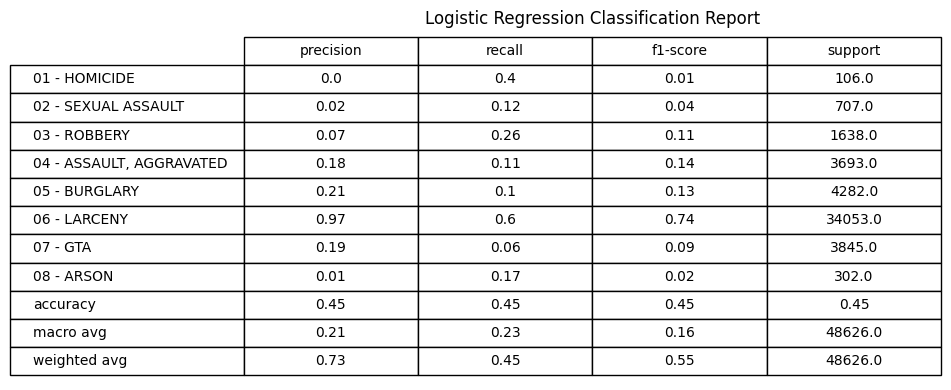

In [16]:
lr_report_dict = classification_report(y_test, lr_predictions, target_names = le.classes_, output_dict = True)
lr_report_df = pd.DataFrame(lr_report_dict).transpose()

fig, ax = plt.subplots(figsize = (10, 4))
ax.axis("off")
table = ax.table(cellText = lr_report_df.round(2).values,
                 rowLabels = lr_report_df.index,
                 colLabels = lr_report_df.columns,
                 loc = "center",
                 cellLoc = "center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title("Logistic Regression Classification Report")
plt.tight_layout()
plt.savefig("../results/03/lr_classification_report.png", dpi = 150, bbox_inches = "tight")
plt.show()

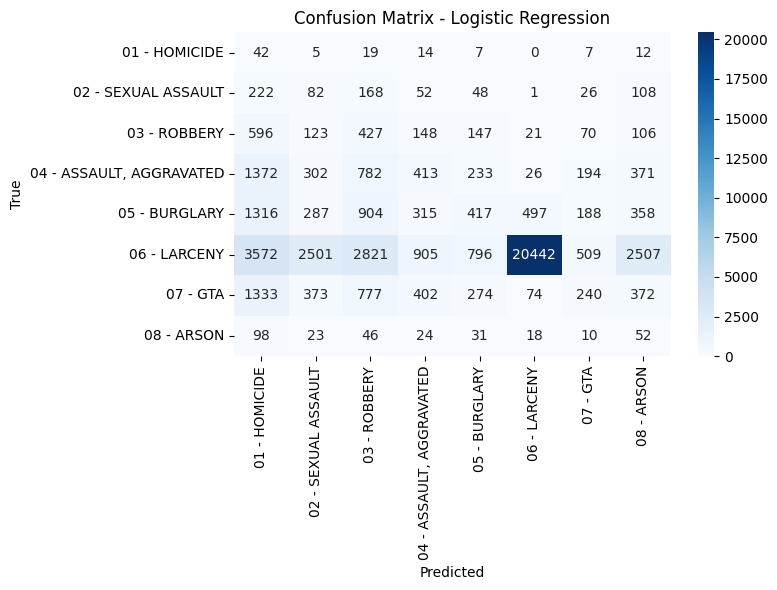

In [17]:
# confusion Matrix for Logistic Regression
lr_cm = confusion_matrix(y_test, lr_predictions)
plt.figure(figsize = (8, 6))
sns.heatmap(lr_cm, annot = True, fmt = "d", cmap = "Blues",
            xticklabels = le.classes_, yticklabels = le.classes_)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("../results/03/lr_confusion_matrix.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [18]:
# Linear Discriminant Analysis

n_classes = len(le.classes_)
lda_model = LinearDiscriminantAnalysis(priors = np.ones(n_classes) / n_classes)
lda_model.fit(X_train_scaled, y_train)
lda_predictions = lda_model.predict(X_test_scaled)

lda_report = classification_report(y_test, lda_predictions, target_names = le.classes_)
print(lda_report)

                          precision    recall  f1-score   support

           01 - HOMICIDE       0.01      0.32      0.01       106
     02 - SEXUAL ASSAULT       0.02      0.04      0.03       707
            03 - ROBBERY       0.08      0.27      0.12      1638
04 - ASSAULT, AGGRAVATED       0.19      0.13      0.15      3693
           05 - BURGLARY       0.20      0.17      0.19      4282
            06 - LARCENY       0.95      0.66      0.78     34053
                07 - GTA       0.19      0.08      0.11      3845
              08 - ARSON       0.01      0.15      0.02       302

                accuracy                           0.50     48626
               macro avg       0.21      0.23      0.18     48626
            weighted avg       0.71      0.50      0.59     48626



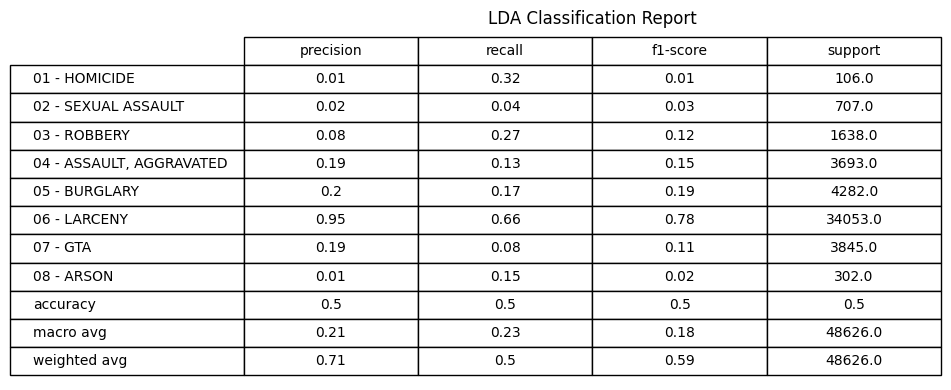

In [19]:
lda_report_dict = classification_report(y_test, lda_predictions, target_names = le.classes_, output_dict = True)
lda_report_df = pd.DataFrame(lda_report_dict).transpose()

fig, ax = plt.subplots(figsize = (10, 4))
ax.axis("off")
table = ax.table(cellText = lda_report_df.round(2).values,
                 rowLabels = lda_report_df.index,
                 colLabels = lda_report_df.columns,
                 loc = "center",
                 cellLoc = "center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title("LDA Classification Report")
plt.tight_layout()
plt.savefig("../results/03/lda_classification_report.png", dpi = 150, bbox_inches = "tight")
plt.show()

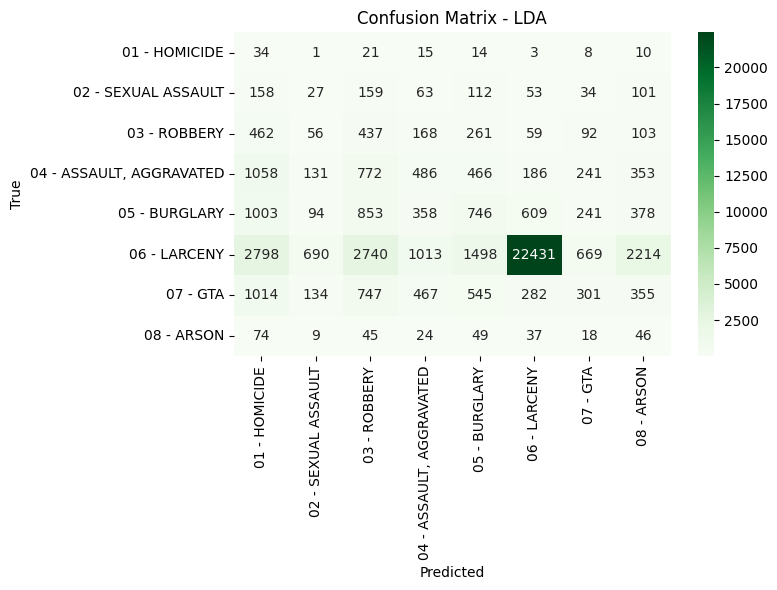

In [20]:
# confusion Matrix for LDA
lda_cm = confusion_matrix(y_test, lda_predictions)
plt.figure(figsize = (8, 6))
sns.heatmap(lda_cm, annot = True, fmt = "d", cmap = "Greens",
            xticklabels = le.classes_, yticklabels = le.classes_)
plt.title("Confusion Matrix - LDA")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("../results/03/lda_confusion_matrix.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [21]:
# Decision Tree

dt_model = DecisionTreeClassifier(random_state = 42, class_weight = "balanced")
dt_model.fit(X_train_selected, y_train)
dt_predictions = dt_model.predict(X_test_selected)
dt_report = classification_report(y_test, dt_predictions, target_names = le.classes_)
print(dt_report)

                          precision    recall  f1-score   support

           01 - HOMICIDE       0.02      0.08      0.03       106
     02 - SEXUAL ASSAULT       0.05      0.18      0.08       707
            03 - ROBBERY       0.09      0.22      0.13      1638
04 - ASSAULT, AGGRAVATED       0.16      0.24      0.19      3693
           05 - BURGLARY       0.16      0.19      0.18      4282
            06 - LARCENY       0.90      0.66      0.76     34053
                07 - GTA       0.17      0.21      0.19      3845
              08 - ARSON       0.04      0.16      0.07       302

                accuracy                           0.52     48626
               macro avg       0.20      0.24      0.20     48626
            weighted avg       0.67      0.52      0.58     48626



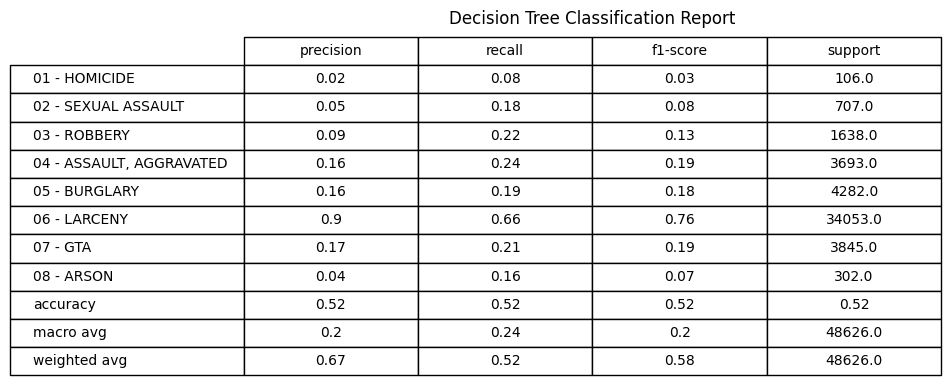

In [22]:
dt_report_dict = classification_report(y_test, dt_predictions, target_names = le.classes_, output_dict = True)
dt_report_df = pd.DataFrame(dt_report_dict).transpose()
fig, ax = plt.subplots(figsize = (10, 4))
ax.axis("off")
table = ax.table(cellText = dt_report_df.round(2).values,
                 rowLabels = dt_report_df.index,
                 colLabels = dt_report_df.columns,
                 loc = "center",
                 cellLoc = "center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title("Decision Tree Classification Report")
plt.tight_layout()
plt.savefig("../results/03/dt_classification_report.png", dpi = 150, bbox_inches = "tight")
plt.show()

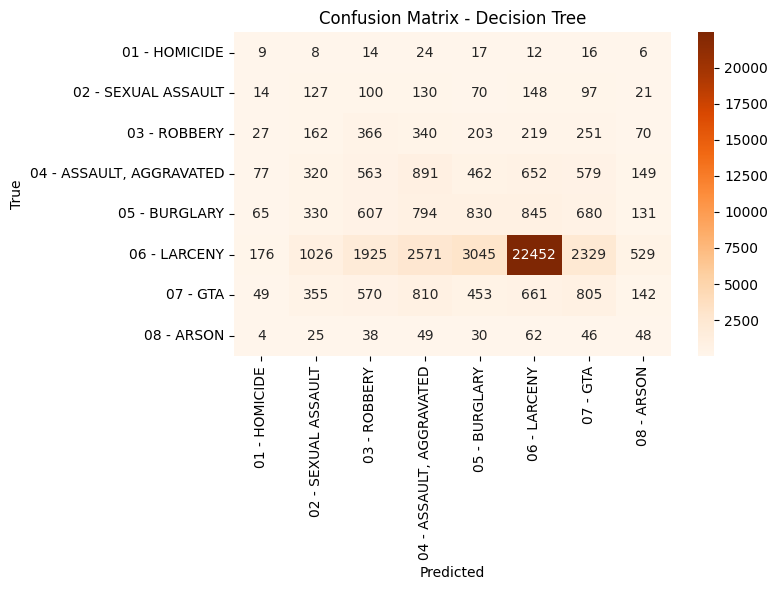

In [23]:
# confusion matrix for Decision Tree
dt_cm = confusion_matrix(y_test, dt_predictions)
plt.figure(figsize = (8, 6))
sns.heatmap(dt_cm, annot = True, fmt = "d", cmap = "Oranges",
            xticklabels = le.classes_, yticklabels = le.classes_)   
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()  
plt.savefig("../results/03/dt_confusion_matrix.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [24]:
# Random Forest

rf_model = RandomForestClassifier(random_state = 42, class_weight = "balanced", n_jobs = -1)
rf_model.fit(X_train_selected, y_train)
rf_predictions = rf_model.predict(X_test_selected)
rf_report = classification_report(y_test, rf_predictions, target_names = le.classes_)
print(rf_report)

                          precision    recall  f1-score   support

           01 - HOMICIDE       0.02      0.08      0.04       106
     02 - SEXUAL ASSAULT       0.05      0.15      0.08       707
            03 - ROBBERY       0.08      0.18      0.11      1638
04 - ASSAULT, AGGRAVATED       0.17      0.22      0.19      3693
           05 - BURGLARY       0.18      0.20      0.19      4282
            06 - LARCENY       0.88      0.71      0.79     34053
                07 - GTA       0.18      0.22      0.20      3845
              08 - ARSON       0.05      0.15      0.07       302

                accuracy                           0.56     48626
               macro avg       0.20      0.24      0.21     48626
            weighted avg       0.66      0.56      0.60     48626



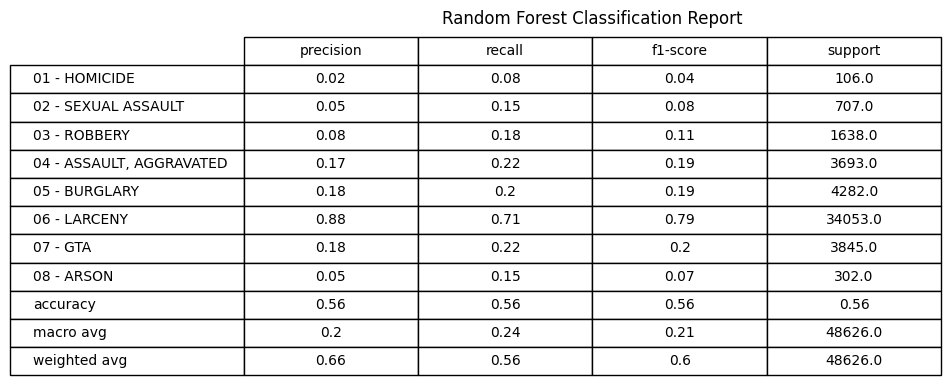

In [25]:
rf_report_dict = classification_report(y_test, rf_predictions, target_names = le.classes_, output_dict = True)
rf_report_df = pd.DataFrame(rf_report_dict).transpose()
fig, ax = plt.subplots(figsize = (10, 4))
ax.axis("off")
table = ax.table(cellText = rf_report_df.round(2).values,
                    rowLabels = rf_report_df.index,
                    colLabels = rf_report_df.columns,
                    loc = "center",
                    cellLoc = "center") 
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title("Random Forest Classification Report")
plt.tight_layout()
plt.savefig("../results/03/rf_classification_report.png", dpi = 150, bbox_inches = "tight")
plt.show()

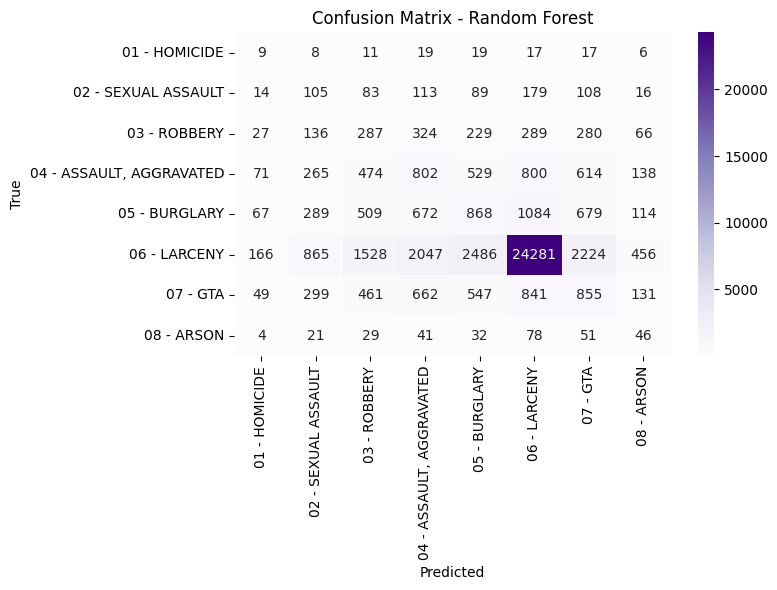

In [26]:
## confusion matrix for Random Forest
rf_cm = confusion_matrix(y_test, rf_predictions)
plt.figure(figsize = (8, 6))
sns.heatmap(rf_cm, annot = True, fmt = "d", cmap = "Purples",
            xticklabels = le.classes_, yticklabels = le.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("../results/03/rf_confusion_matrix.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [27]:
# Support Vector Machine

svm_model = SVC(kernel = "rbf", random_state = 42, class_weight = "balanced")
svm_model.fit(X_train_scaled, y_train)
svm_predictions = svm_model.predict(X_test_scaled)
svm_report = classification_report(y_test, svm_predictions, target_names = le.classes_)
print(svm_report)

                          precision    recall  f1-score   support

           01 - HOMICIDE       0.01      0.31      0.01       106
     02 - SEXUAL ASSAULT       0.03      0.20      0.05       707
            03 - ROBBERY       0.08      0.20      0.11      1638
04 - ASSAULT, AGGRAVATED       0.16      0.09      0.12      3693
           05 - BURGLARY       0.20      0.09      0.12      4282
            06 - LARCENY       0.96      0.62      0.76     34053
                07 - GTA       0.17      0.11      0.14      3845
              08 - ARSON       0.02      0.25      0.03       302

                accuracy                           0.47     48626
               macro avg       0.20      0.23      0.17     48626
            weighted avg       0.72      0.47      0.56     48626



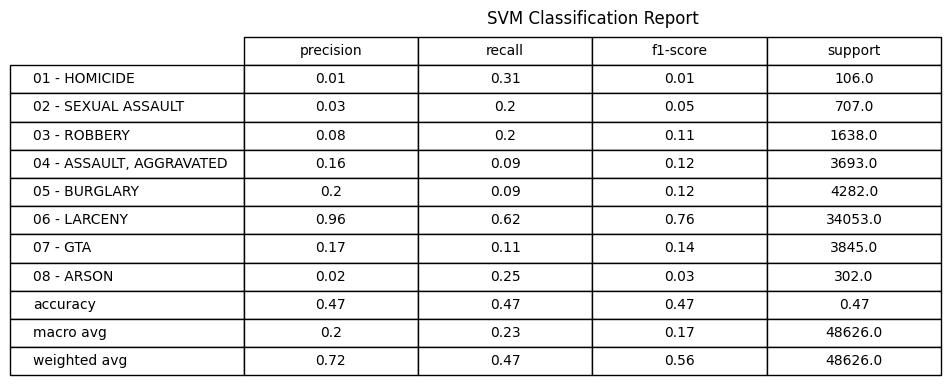

In [30]:
svm_report_dict = classification_report(y_test, svm_predictions, target_names = le.classes_, output_dict = True)
svm_report_df = pd.DataFrame(svm_report_dict).transpose()
fig, ax = plt.subplots(figsize = (10, 4))
ax.axis("off")
table = ax.table(cellText = svm_report_df.round(2).values,
                    rowLabels = svm_report_df.index,
                    colLabels = svm_report_df.columns,
                    loc = "center",
                    cellLoc = "center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title("SVM Classification Report")
plt.tight_layout()
plt.savefig("../results/03/svm_classification_report.png", dpi = 150, bbox_inches = "tight")
plt.show()

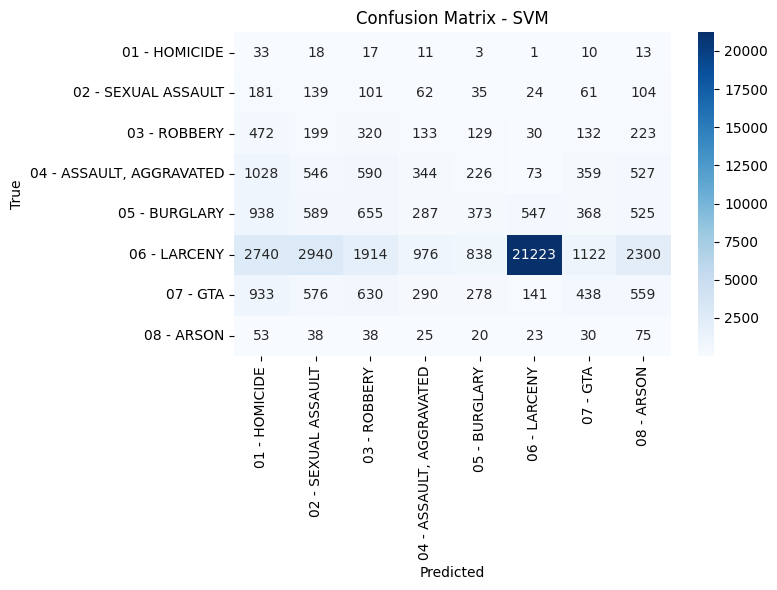

In [29]:
# confusion matrix for SVM
svm_cm = confusion_matrix(y_test, svm_predictions)
plt.figure(figsize = (8, 6))
sns.heatmap(svm_cm, annot = True, fmt = "d", cmap = "Blues",
            xticklabels = le.classes_, yticklabels = le.classes_)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("../results/03/svm_confusion_matrix.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [32]:
# K fold Cross Validation

skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

models = {
    "Logistic Regression": (lr_model, X_train_scaled, y_train),
    "LDA": (lda_model, X_train_scaled, y_train),
    "Decision Tree": (dt_model, X_train_selected, y_train),
    "Random Forest": (rf_model, X_train_selected, y_train),
    "SVM": (svm_model, X_train_scaled, y_train)
}

for name, (model, X, y) in models.items():
    scores = cross_val_score(model, X, y, cv = skf, scoring = "f1_macro", n_jobs = -1)
    print(f"{name} - CV F1 Macro: {scores.mean():.4f} +/- {scores.std():.4f}")

Logistic Regression - CV F1 Macro: 0.1637 +/- 0.0011
LDA - CV F1 Macro: 0.1780 +/- 0.0011
Decision Tree - CV F1 Macro: 0.2045 +/- 0.0025
Random Forest - CV F1 Macro: 0.2090 +/- 0.0018
SVM - CV F1 Macro: 0.1683 +/- 0.0006


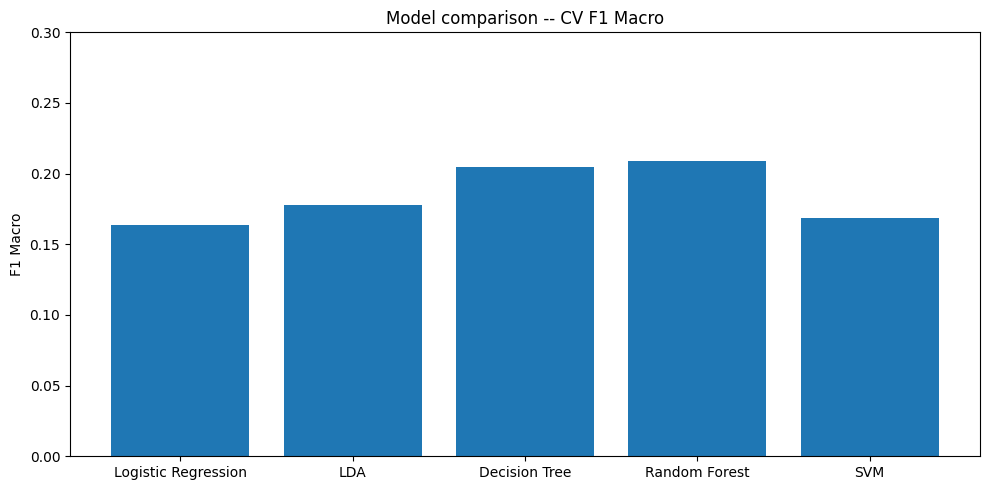

In [33]:
cv_scores = {
    "Logistic Regression": 0.1637,
    "LDA": 0.1780,
    "Decision Tree": 0.2045,
    "Random Forest": 0.2090,
    "SVM": 0.1683
}

plt.figure(figsize = (10, 5))
plt.bar(cv_scores.keys(), cv_scores.values())
plt.title("Model comparison -- CV F1 Macro")
plt.ylabel("F1 Macro")
plt.ylim(0, 0.3)
plt.tight_layout()
plt.savefig("../results/03/model_comparison.png", dpi = 150, bbox_inches = "tight")
plt.show()

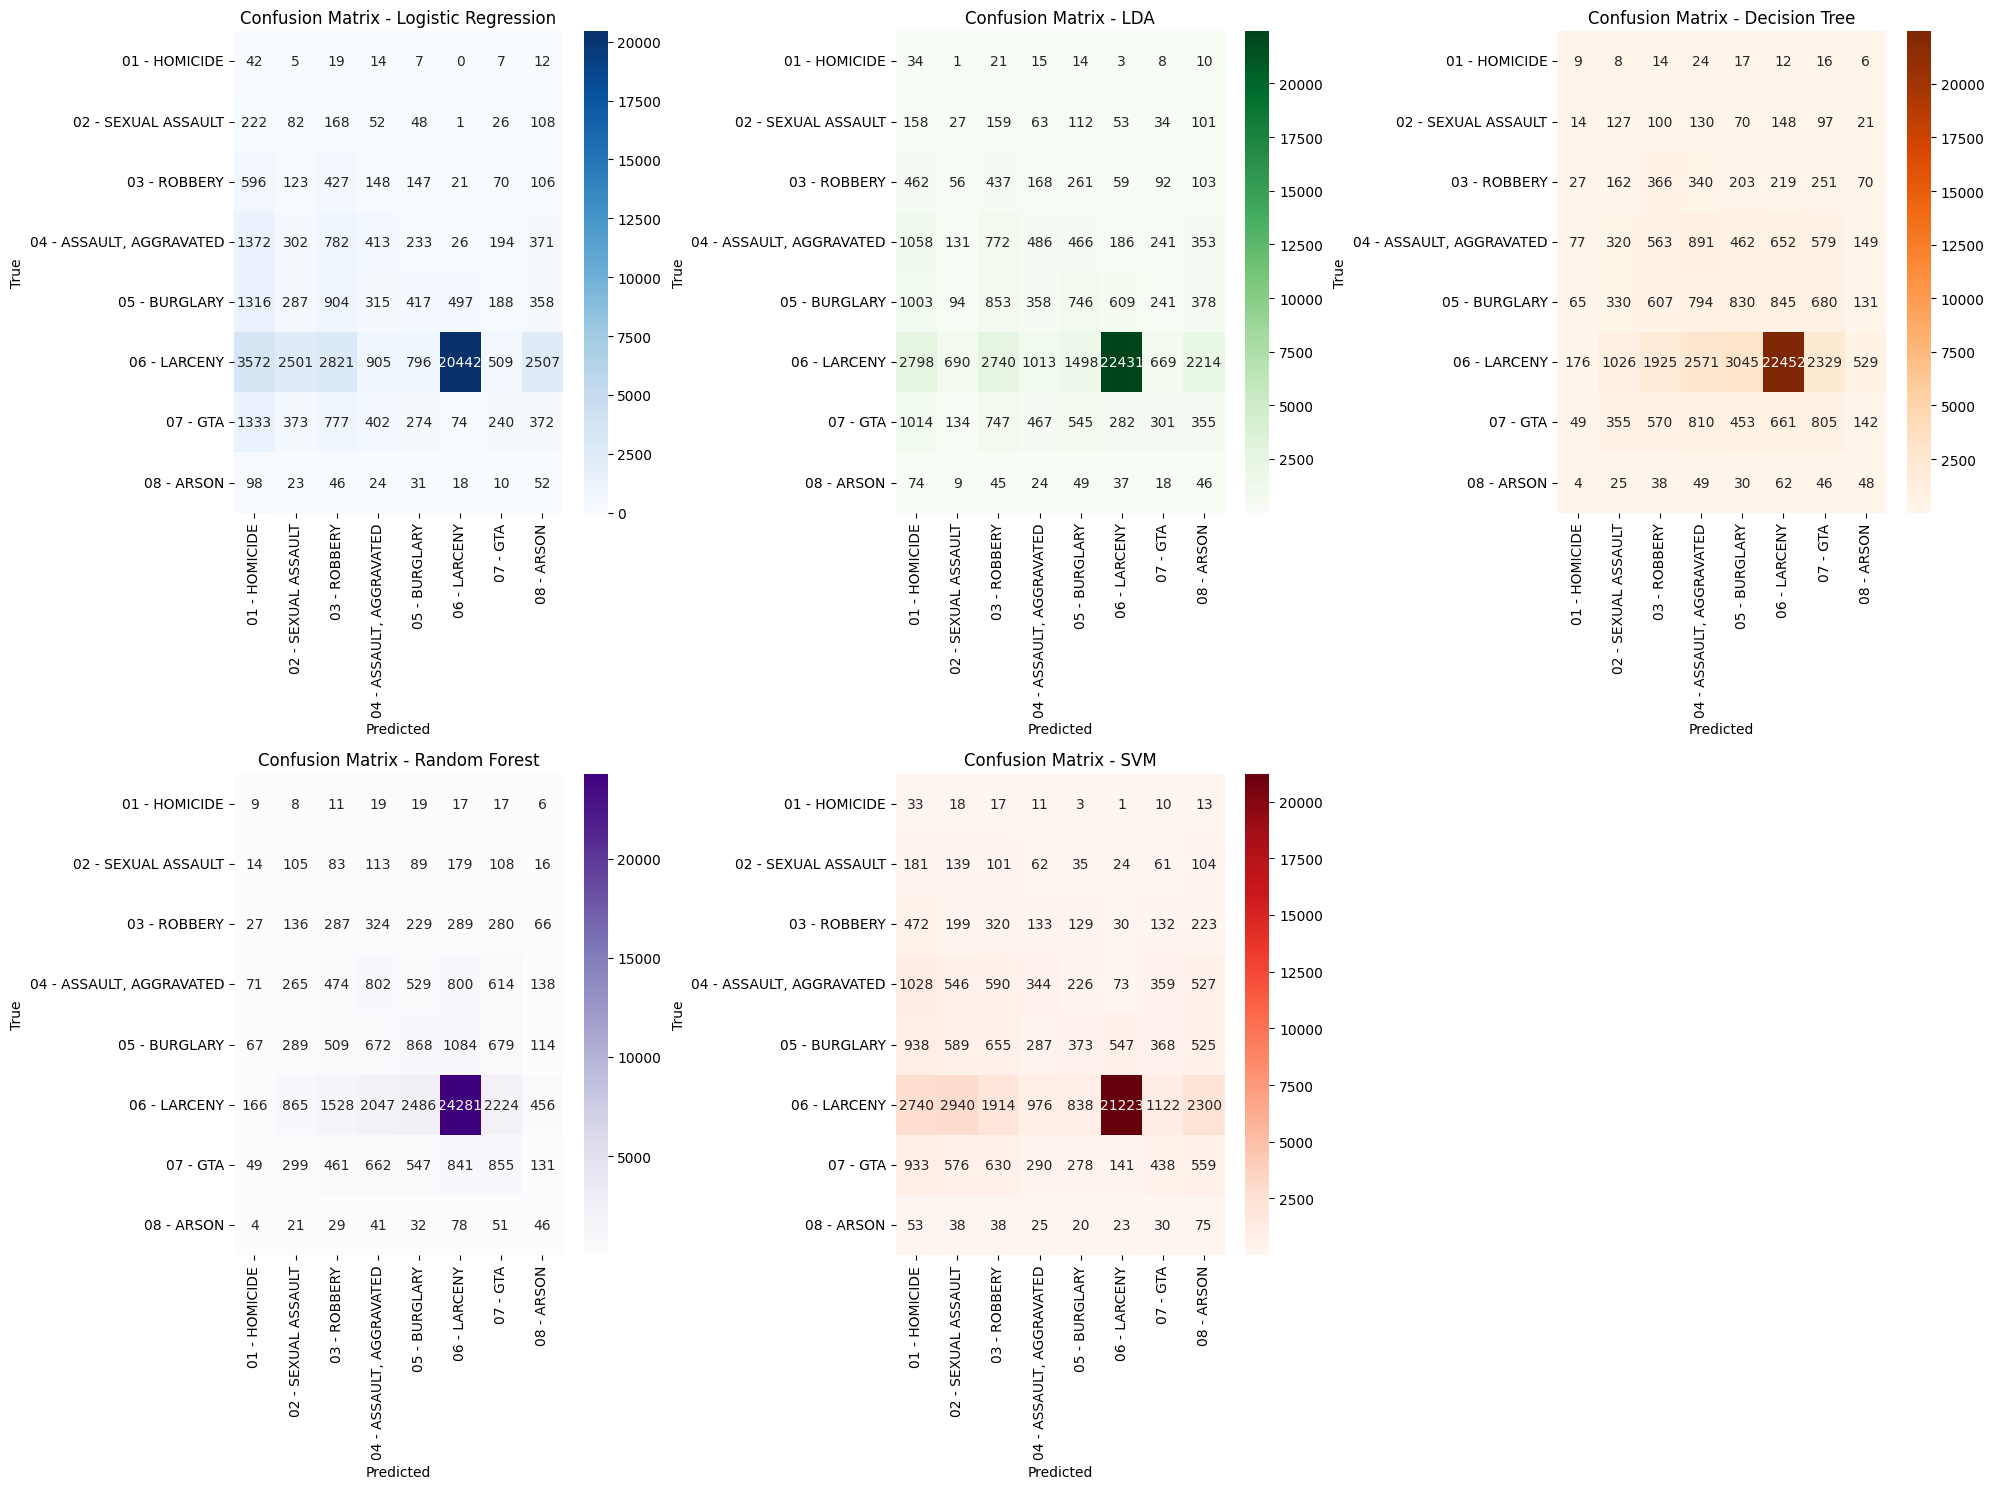

In [34]:
# confusionmatrix comparison

lr_cm = confusion_matrix(y_test, lr_predictions)
lda_cm = confusion_matrix(y_test, lda_predictions)
dt_cm = confusion_matrix(y_test, dt_predictions)
rf_cm = confusion_matrix(y_test, rf_predictions)
svm_cm = confusion_matrix(y_test, svm_predictions)

cm_models = {
    "Logistic Regression": (lr_cm, "Blues"),    
    "LDA": (lda_cm, "Greens"),
    "Decision Tree": (dt_cm, "Oranges"),
    "Random Forest": (rf_cm, "Purples"),
    "SVM": (svm_cm, "Reds")
}

plt.figure(figsize = (20, 15))
for i, (name, (cm, cmap)) in enumerate(cm_models.items()):
    plt.subplot(2, 3, i + 1)
    sns.heatmap(cm, annot = True, fmt = "d", cmap = cmap,
                xticklabels = le.classes_, yticklabels = le.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")  
plt.tight_layout()
plt.savefig("../results/03/confusion_matrix_comparison.png", dpi = 150, bbox_inches = "tight")
plt.show()